In [ ]:
# Install dependencies (run on Google Colab)
!pip install -q jax jaxlib optax flax matplotlib

In [44]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt
import numpy as np
import math

print(f"JAX version: {jax.__version__}")
print(f"Backend: {jax.default_backend()}")

key = jax.random.PRNGKey(42)

JAX version: 0.9.1
Backend: cpu


Learned: w = -3.4659, b = 0.0056
True:    w = -3.5000, b = 0.0000
Recovered spring constant: k = 3.4659 (true: 3.5)


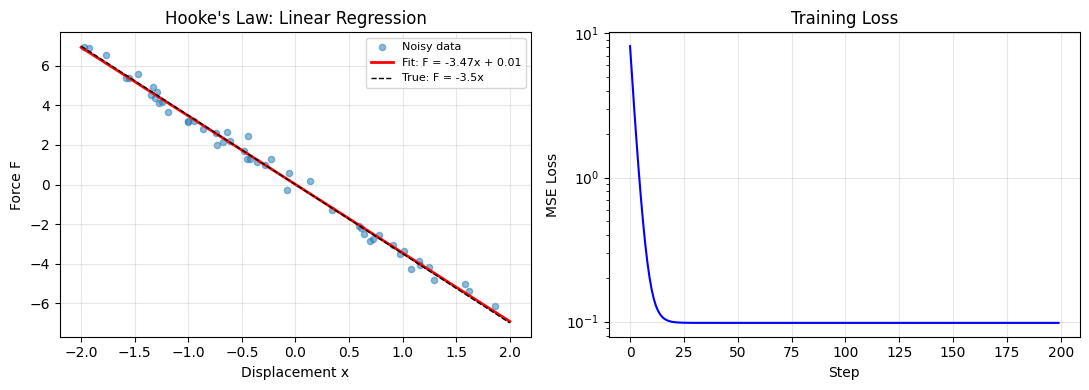

In [45]:
# Generate noisy Hooke's law data
k_true = 3.5
N_data = 50

key, k1, k2 = jax.random.split(key, 3)
x_data = jax.random.uniform(k1, (N_data,), minval=-2.0, maxval=2.0)
F_data = -k_true * x_data + 0.3 * jax.random.normal(k2, (N_data,))

# Linear model: F_pred = w * x + b
def linear_loss(params, x, y):
    w, b = params
    return jnp.mean((w * x + b - y) ** 2)

# Manual SGD
grad_fn = jax.grad(linear_loss)
params = (0.0, 0.0)
lr = 0.1
losses = []

for step in range(200):
    grads = grad_fn(params, x_data, F_data)
    params = (params[0] - lr * grads[0], params[1] - lr * grads[1])
    losses.append(float(linear_loss(params, x_data, F_data)))

w_learned, b_learned = params
print(f"Learned: w = {w_learned:.4f}, b = {b_learned:.4f}")
print(f"True:    w = {-k_true:.4f}, b = 0.0000")
print(f"Recovered spring constant: k = {-w_learned:.4f} (true: {k_true})")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.scatter(x_data, F_data, alpha=0.5, s=20, label='Noisy data')
x_fit = jnp.linspace(-2, 2, 100)
ax1.plot(x_fit, w_learned * x_fit + b_learned, 'r-', lw=2,
         label=f'Fit: F = {w_learned:.2f}x + {b_learned:.2f}')
ax1.plot(x_fit, -k_true * x_fit, 'k--', lw=1, label=f'True: F = -{k_true}x')
ax1.set_xlabel('Displacement x'); ax1.set_ylabel('Force F')
ax1.set_title("Hooke's Law: Linear Regression")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.plot(losses, 'b-', lw=1.5)
ax2.set_xlabel('Step'); ax2.set_ylabel('MSE Loss')
ax2.set_title('Training Loss'); ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [46]:
def init_mlp(key, layer_sizes):
    """Initialize MLP parameters with He initialization."""
    params = []
    for i in range(len(layer_sizes) - 1):
        key, sk = jax.random.split(key)
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        W = jax.random.normal(sk, (n_in, n_out)) * jnp.sqrt(2.0 / n_in)
        b = jnp.zeros(n_out)
        params.append((W, b))
    return params


def mlp_forward(params, x, activation=jax.nn.relu):
    """Forward pass: hidden layers with activation, linear output."""
    for W, b in params[:-1]:
        x = activation(x @ W + b)
    W, b = params[-1]
    return x @ W + b  # no activation on output


# Create [1, 64, 64, 1] network and inspect
key, sk = jax.random.split(key)
test_params = init_mlp(sk, [1, 64, 64, 1])

total_params = 0
for i, (W, b) in enumerate(test_params):
    n = W.size + b.size
    total_params += n
    print(f"Layer {i+1}: W {W.shape}, b {b.shape} -> {n} parameters")
print(f"Total parameters: {total_params}")

# Test forward pass
x_test = jnp.linspace(-3, 3, 100).reshape(-1, 1)
y_test = mlp_forward(test_params, x_test)
print(f"\nInput shape:  {x_test.shape}")
print(f"Output shape: {y_test.shape}")

Layer 1: W (1, 64), b (64,) -> 128 parameters
Layer 2: W (64, 64), b (64,) -> 4160 parameters
Layer 3: W (64, 1), b (1,) -> 65 parameters
Total parameters: 4353

Input shape:  (100, 1)
Output shape: (100, 1)


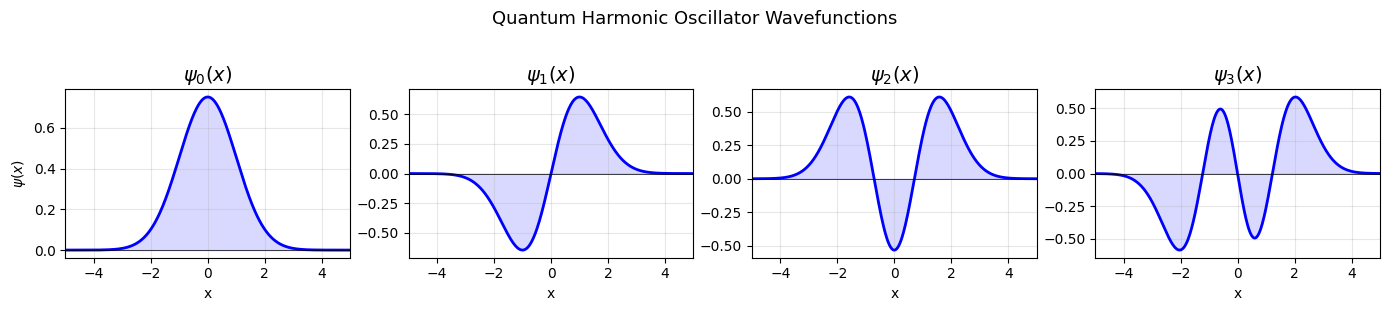

n=0: Gaussian (no nodes) — easy
n=1: 1 node — network must learn sign change
n=2: 2 nodes — needs oscillatory behavior
n=3: 3 nodes — most challenging for small networks


In [47]:
def hermite(n, x):
    """Physicist's Hermite polynomial H_n(x) via recurrence."""
    if n == 0:
        return jnp.ones_like(x)
    elif n == 1:
        return 2 * x
    H_prev, H_curr = jnp.ones_like(x), 2 * x
    for k in range(2, n + 1):
        H_prev, H_curr = H_curr, 2 * x * H_curr - 2 * (k - 1) * H_prev
    return H_curr


def psi_n(x, n):
    """QHO wavefunction psi_n(x) with m=omega=hbar=1."""
    norm = 1.0 / jnp.sqrt(2**n * math.factorial(n) * jnp.sqrt(jnp.pi))
    return norm * jnp.exp(-x**2 / 2) * hermite(n, x)


# Plot the first four wavefunctions
x_plot = jnp.linspace(-5, 5, 500)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for n, ax in enumerate(axes):
    psi = psi_n(x_plot, n)
    ax.plot(x_plot, psi, 'b-', lw=2)
    ax.axhline(0, color='k', lw=0.5)
    ax.fill_between(x_plot, psi, alpha=0.15, color='blue')
    ax.set_title(f'$\\psi_{n}(x)$', fontsize=14)
    ax.set_xlabel('x'); ax.set_xlim(-5, 5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$\\psi(x)$')
plt.suptitle('Quantum Harmonic Oscillator Wavefunctions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("n=0: Gaussian (no nodes) — easy")
print("n=1: 1 node — network must learn sign change")
print("n=2: 2 nodes — needs oscillatory behavior")
print("n=3: 3 nodes — most challenging for small networks")

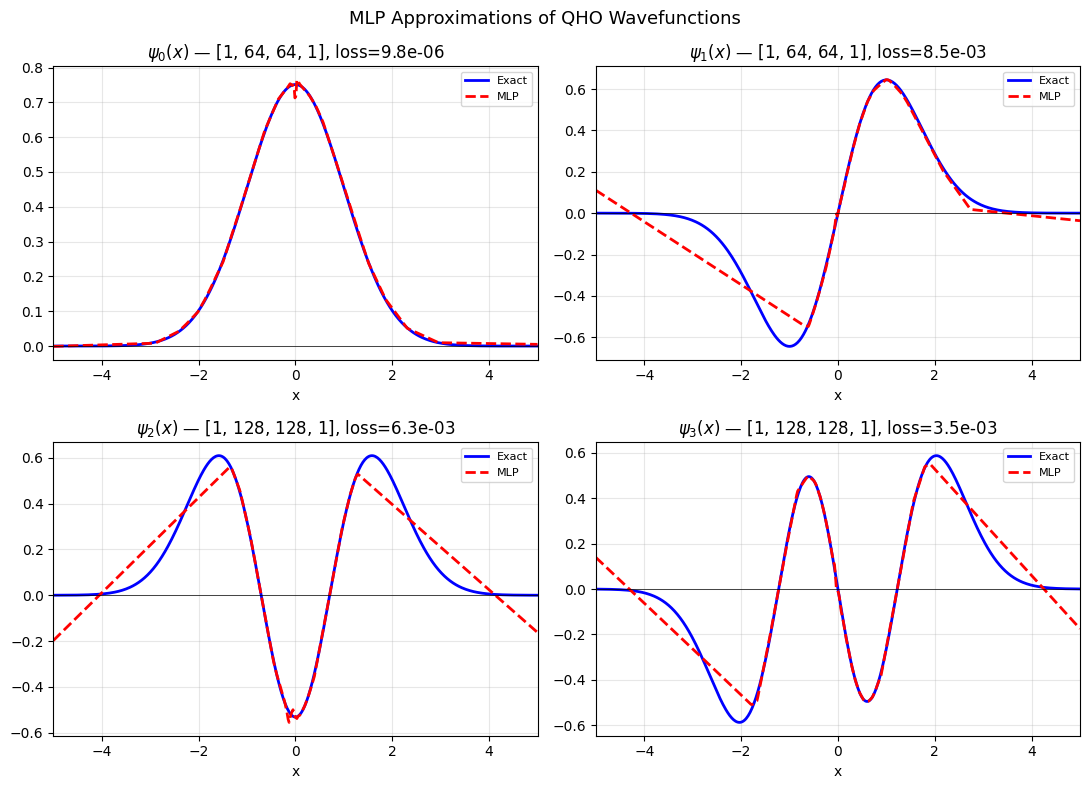

Observations:
  - psi_0: Gaussian — easy for any network
  - psi_1: Sign change — network learns a node
  - psi_2, psi_3: Multiple nodes — wider networks needed


In [50]:
# Fit all four states: psi_0 through psi_3
# Higher states have more nodes -> wider networks help

network_configs = {
    0: [1, 64, 64, 1],
    1: [1, 64, 64, 1],
    2: [1, 128, 128, 1],
    3: [1, 128, 128, 1],
}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)

for n_state, ax in enumerate(axes.flatten()):
    # Training data
    key, k1, k2 = jax.random.split(key, 3)
    x_tr = jax.random.uniform(k1, (300, 1), minval=-5.0, maxval=5.0)
    y_tr = psi_n(x_tr[:, 0], n_state).reshape(-1, 1)

    # Initialize and train
    sizes = network_configs[n_state]
    p = init_mlp(k2, sizes)
    tx_n, step_n, _ = make_trainer(lr=1e-3)
    opt_n = tx_n.init(p)

    for epoch in range(5000):
        p, opt_n, loss = step_n(p, opt_n, x_tr, y_tr)

    # Plot
    y_pred_n = mlp_forward(p, x_eval)
    y_exact_n = psi_n(x_eval[:, 0], n_state)

    ax.plot(x_eval, y_exact_n, 'b-', lw=2, label='Exact')
    ax.plot(x_eval, y_pred_n, 'r--', lw=2, label='MLP')
    ax.set_title(f'$\\psi_{n_state}(x)$ — {sizes}, loss={float(loss):.1e}')
    ax.set_xlabel('x'); ax.axhline(0, color='k', lw=0.5)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(-5, 5)

plt.suptitle('MLP Approximations of QHO Wavefunctions', fontsize=13)
plt.tight_layout()
plt.show()

print("Observations:")
print("  - psi_0: Gaussian — easy for any network")
print("  - psi_1: Sign change — network learns a node")
print("  - psi_2, psi_3: Multiple nodes — wider networks needed")

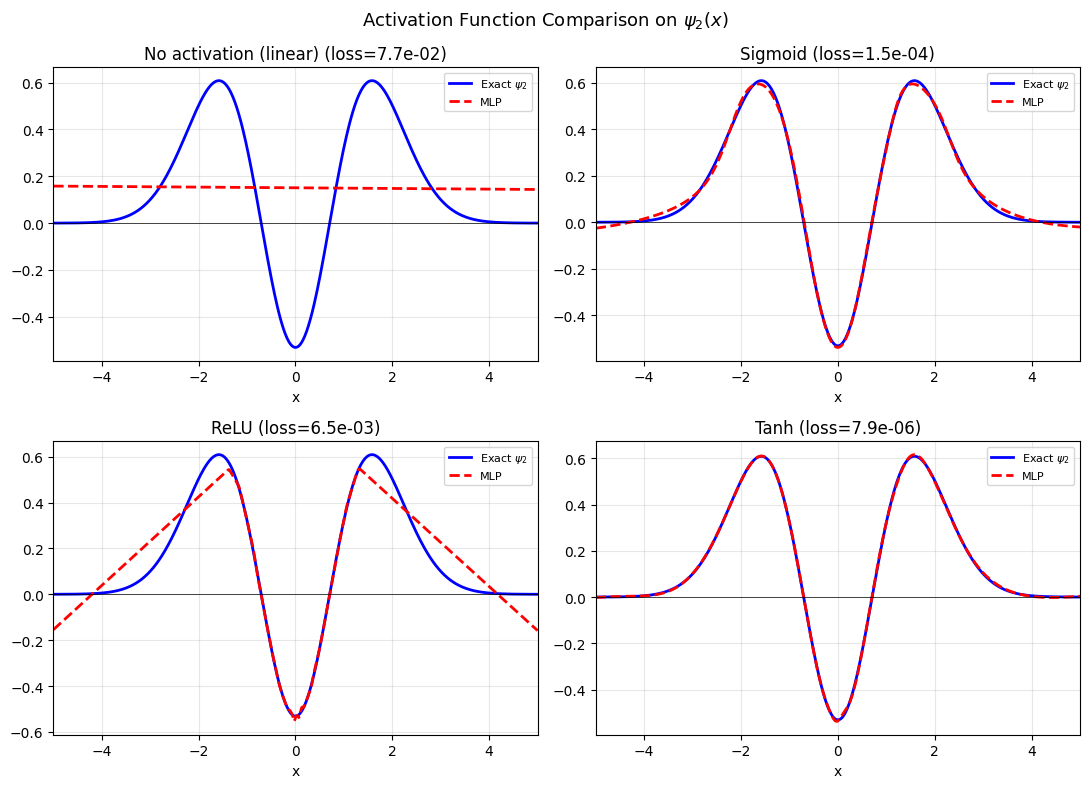

Observations:
  - Linear: cannot represent nonlinear functions
  - Sigmoid: slow convergence (vanishing gradients)
  - ReLU: piecewise linear — reasonable fit
  - Tanh: smooth, zero-centered — best for smooth targets


In [51]:
target_n = 2

key, sk = jax.random.split(key)
x_act = jax.random.uniform(sk, (300, 1), minval=-5.0, maxval=5.0)
y_act = psi_n(x_act[:, 0], target_n).reshape(-1, 1)

activations = [
    ('No activation (linear)', lambda x: x),
    ('Sigmoid', jax.nn.sigmoid),
    ('ReLU', jax.nn.relu),
    ('Tanh', jnp.tanh),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
y_exact_act = psi_n(x_eval[:, 0], target_n)

for (name, act_fn), ax in zip(activations, axes.flatten()):
    key, sk = jax.random.split(key)
    p = init_mlp(sk, [1, 128, 128, 1])
    tx_a, step_a, _ = make_trainer(lr=1e-3, activation=act_fn)
    opt_a = tx_a.init(p)

    for epoch in range(3000):
        p, opt_a, loss = step_a(p, opt_a, x_act, y_act)

    y_pred_a = mlp_forward(p, x_eval, activation=act_fn)
    ax.plot(x_eval, y_exact_act, 'b-', lw=2, label='Exact $\\psi_2$')
    ax.plot(x_eval, y_pred_a, 'r--', lw=2, label='MLP')
    ax.set_title(f'{name} (loss={float(loss):.1e})')
    ax.set_xlabel('x'); ax.axhline(0, color='k', lw=0.5)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(-5, 5)

plt.suptitle(f'Activation Function Comparison on $\\psi_{target_n}(x)$', fontsize=13)
plt.tight_layout()
plt.show()

print("Observations:")
print("  - Linear: cannot represent nonlinear functions")
print("  - Sigmoid: slow convergence (vanishing gradients)")
print("  - ReLU: piecewise linear — reasonable fit")
print("  - Tanh: smooth, zero-centered — best for smooth targets")

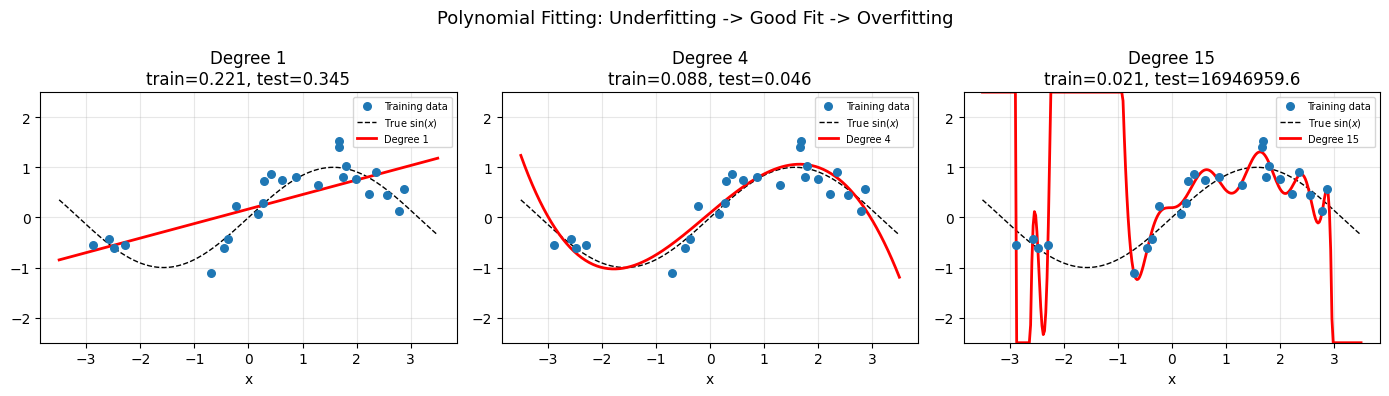

Degree 1:  underfits (can't capture curvature)
Degree 4:  good fit (captures the true pattern)
Degree 15: overfits (passes through noise, wild oscillations)


In [52]:
np.random.seed(0)
N_poly = 25
x_poly = np.sort(np.random.uniform(-3, 3, N_poly))
y_poly_noisy = np.sin(x_poly) + 0.3 * np.random.randn(N_poly)

x_eval_poly = np.linspace(-3.5, 3.5, 300)
y_eval_true = np.sin(x_eval_poly)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, degree in zip(axes, [1, 4, 15]):
    coeffs = np.polyfit(x_poly, y_poly_noisy, degree)
    y_fit_train = np.polyval(coeffs, x_poly)
    y_fit_eval = np.polyval(coeffs, x_eval_poly)

    train_mse = np.mean((y_fit_train - y_poly_noisy) ** 2)
    test_mse = np.mean((y_fit_eval - y_eval_true) ** 2)

    ax.scatter(x_poly, y_poly_noisy, s=30, zorder=5, label='Training data')
    ax.plot(x_eval_poly, y_eval_true, 'k--', lw=1, label='True $\\sin(x)$')
    ax.plot(x_eval_poly, np.clip(y_fit_eval, -2.5, 2.5), 'r-', lw=2,
            label=f'Degree {degree}')
    title = f'Degree {degree}\ntrain={train_mse:.3f}, test={test_mse:.1f}' \
            if test_mse > 10 else \
            f'Degree {degree}\ntrain={train_mse:.3f}, test={test_mse:.3f}'
    ax.set_title(title)
    ax.set_ylim(-2.5, 2.5); ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3); ax.set_xlabel('x')

plt.suptitle('Polynomial Fitting: Underfitting -> Good Fit -> Overfitting',
             fontsize=13)
plt.tight_layout()
plt.show()

print("Degree 1:  underfits (can't capture curvature)")
print("Degree 4:  good fit (captures the true pattern)")
print("Degree 15: overfits (passes through noise, wild oscillations)")

In [ ]:
key, k1, k2, k3 = jax.random.split(key, 4)
N_small = 20  # small training set to demonstrate overfitting
x_small = jax.random.uniform(k1, (N_small, 1), minval=-3.0, maxval=3.0)
y_small = jnp.sin(x_small) + 0.3 * jax.random.normal(k2, (N_small, 1))

# Test set: dense, clean targets
x_nn_test = jnp.linspace(-3.5, 3.5, 300).reshape(-1, 1)
y_nn_test = jnp.sin(x_nn_test)

configs = [
    ('Small [1,16,1]', [1, 16, 1]),
    ('Medium [1,64,64,1]', [1, 64, 64, 1]),
    ('Large [1,256,256,1]', [1, 256, 256, 1]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

trained_models = []
for idx, ((name, sizes), ax_top, ax_bot) in enumerate(
        zip(configs, axes[0], axes[1])):
    key, sk = jax.random.split(key)
    p = init_mlp(sk, sizes)
    n_params = sum(W.size + b.size for W, b in p)

    tx_o, step_o, loss_fn_o = make_trainer(lr=1e-3)
    opt_o = tx_o.init(p)

    train_hist, test_hist, epoch_hist = [], [], []
    for epoch in range(8000):
        p, opt_o, loss = step_o(p, opt_o, x_small, y_small)
        if epoch % 50 == 0:
            train_hist.append(float(loss))
            test_hist.append(float(loss_fn_o(p, x_nn_test, y_nn_test)))
            epoch_hist.append(epoch)

    trained_models.append((p, n_params, train_hist, test_hist))

    # Top row: predictions
    y_pred_o = mlp_forward(p, x_nn_test)
    ax_top.plot(x_nn_test, jnp.sin(x_nn_test), 'k--', lw=1.5, label='True $\\sin(x)$')
    ax_top.plot(x_nn_test, y_pred_o, 'r-', lw=2, label='MLP prediction')
    ax_top.scatter(x_small, y_small, s=30, zorder=5, color='C0', label='Train data')
    ax_top.set_title(f'{name}\n({n_params} params)')
    ax_top.set_ylim(-2.0, 2.0); ax_top.set_xlim(-3.5, 3.5)
    ax_top.legend(fontsize=7); ax_top.grid(True, alpha=0.3)

    # Bottom row: loss curves
    ax_bot.plot(epoch_hist, train_hist, 'b-', lw=1.5, label='Train loss')
    ax_bot.plot(epoch_hist, test_hist, 'r-', lw=1.5, label='Test loss')
    ax_bot.set_xlabel('Epoch'); ax_bot.set_ylabel('MSE')
    gap = test_hist[-1] - train_hist[-1]
    ax_bot.set_title(f'Train={train_hist[-1]:.3f}, Test={test_hist[-1]:.3f}, Gap={gap:.3f}')
    ax_bot.legend(fontsize=8); ax_bot.grid(True, alpha=0.3); ax_bot.set_yscale('log')

plt.suptitle(f'Overfitting: More Parameters + Few Data ({N_small} points) = Memorization',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"With only {N_small} training points:")
print("  - Small network:  smooth interpolation, generalizes well")
print("  - Large network:  wiggly fit through noise, poor generalization")
print("  - The train/test GAP grows with model capacity")

In [54]:
# Gradient check on a tiny network
key, sk = jax.random.split(key)
tiny_params = init_mlp(sk, [1, 4, 1])
x_check = jnp.array([[1.5]])
y_check = jnp.array([[0.7]])


def flat_loss(flat_p, shapes, x, y):
    """Reconstruct params from flat vector and compute loss."""
    params = []
    idx = 0
    for w_shape, b_shape in shapes:
        w_size = w_shape[0] * w_shape[1]
        W = flat_p[idx:idx + w_size].reshape(w_shape)
        idx += w_size
        b = flat_p[idx:idx + b_shape[0]]
        idx += b_shape[0]
        params.append((W, b))
    pred = mlp_forward(params, x)
    return jnp.mean((pred - y) ** 2)


flat_p = jnp.concatenate([jnp.concatenate([W.ravel(), b.ravel()])
                          for W, b in tiny_params])
shapes = [(W.shape, b.shape) for W, b in tiny_params]

# Automatic differentiation
auto_grad = jax.grad(flat_loss)(flat_p, shapes, x_check, y_check)

# Finite differences
eps = 1e-5
fd_grad = []
for i in range(len(flat_p)):
    p_plus = flat_p.at[i].add(eps)
    p_minus = flat_p.at[i].add(-eps)
    g = (flat_loss(p_plus, shapes, x_check, y_check) -
         flat_loss(p_minus, shapes, x_check, y_check)) / (2 * eps)
    fd_grad.append(float(g))
fd_grad = jnp.array(fd_grad)

# Compare — use absolute error when gradient is near zero
print("Parameter | jax.grad   | Finite Diff | Abs Error")
print("-" * 55)
for i in range(len(flat_p)):
    ag, fd = float(auto_grad[i]), float(fd_grad[i])
    abs_err = abs(ag - fd)
    print(f"  theta[{i:2d}] | {ag:+10.6f} | {fd:+10.6f} | {abs_err:.2e}")

max_abs_err = float(jnp.max(jnp.abs(auto_grad - fd_grad)))
print(f"\nMax absolute error: {max_abs_err:.2e}")
print("jax.grad computes EXACT symbolic derivatives — the small error")
print("comes from the finite-difference APPROXIMATION (O(eps^2) ≈ 1e-10),")
print("amplified by float32 precision (~7 significant digits).")

Parameter | jax.grad   | Finite Diff | Abs Error
-------------------------------------------------------
  theta[ 0] |  -0.234412 |  -0.230968 | 3.44e-03
  theta[ 1] |  +0.000000 |  +0.000000 | 0.00e+00
  theta[ 2] |  +0.146407 |  +0.146031 | 3.75e-04
  theta[ 3] |  +1.906904 |  +1.911074 | 4.17e-03
  theta[ 4] |  -0.156274 |  -0.156462 | 1.88e-04
  theta[ 5] |  +0.000000 |  +0.000000 | 0.00e+00
  theta[ 6] |  +0.097604 |  +0.096858 | 7.47e-04
  theta[ 7] |  +1.271269 |  +1.270324 | 9.45e-04
  theta[ 8] |  +2.093246 |  +2.093613 | 3.67e-04
  theta[ 9] |  +0.000000 |  +0.000000 | 0.00e+00
  theta[10] |  +0.238093 |  +0.236928 | 1.16e-03
  theta[11] |  +0.978013 |  +0.979751 | 1.74e-03
  theta[12] |  +0.903198 |  +0.904500 | 1.30e-03

Max absolute error: 4.17e-03
jax.grad computes EXACT symbolic derivatives — the small error
comes from the finite-difference APPROXIMATION (O(eps^2) ≈ 1e-10),
amplified by float32 precision (~7 significant digits).


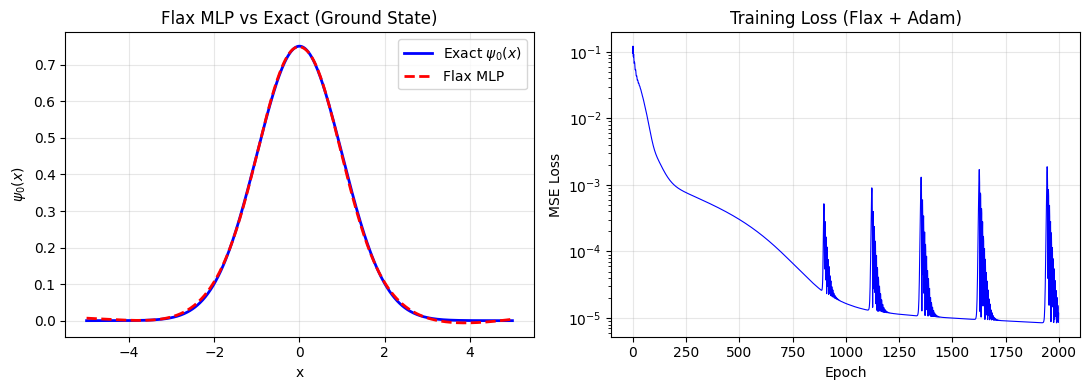

Final loss (Flax + Adam): 1.18e-05

Flax is syntactic sugar over JAX — understand the pure JAX version first.


In [55]:
import flax.nnx as nnx


class QHO_MLP(nnx.Module):
    """MLP for approximating QHO wavefunctions."""

    def __init__(self, hidden_sizes, *, rngs):
        sizes = [1] + hidden_sizes + [1]
        self.layers = nnx.List([
            nnx.Linear(s_in, s_out, rngs=rngs)
            for s_in, s_out in zip(sizes[:-1], sizes[1:])
        ])

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nnx.tanh(layer(x))
        return self.layers[-1](x)  # linear output


# Create model and optimizer
model = QHO_MLP([64, 64], rngs=nnx.Rngs(42))
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)


def flax_loss_fn(model, x, y):
    return jnp.mean((model(x) - y) ** 2)


@nnx.jit
def flax_train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(flax_loss_fn)(model, x, y)
    optimizer.update(model, grads)  # updates model in-place
    return loss


# Training data for psi_0
key, sk = jax.random.split(key)
x_flax = jax.random.uniform(sk, (200, 1), minval=-5.0, maxval=5.0)
y_flax = psi_n(x_flax[:, 0], 0).reshape(-1, 1)

# Train
flax_losses = []
for epoch in range(2000):
    loss = flax_train_step(model, optimizer, x_flax, y_flax)
    flax_losses.append(float(loss))

# Compare with exact
x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
y_flax_pred = model(x_eval)
y_flax_exact = psi_n(x_eval[:, 0], 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(x_eval, y_flax_exact, 'b-', lw=2, label='Exact $\\psi_0(x)$')
ax1.plot(x_eval, y_flax_pred, 'r--', lw=2, label='Flax MLP')
ax1.set_xlabel('x'); ax1.set_ylabel('$\\psi_0(x)$')
ax1.set_title('Flax MLP vs Exact (Ground State)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(flax_losses, 'b-', lw=0.8)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss')
ax2.set_title('Training Loss (Flax + Adam)')
ax2.set_yscale('log'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss (Flax + Adam): {flax_losses[-1]:.2e}")
print("\nFlax is syntactic sugar over JAX — understand the pure JAX version first.")

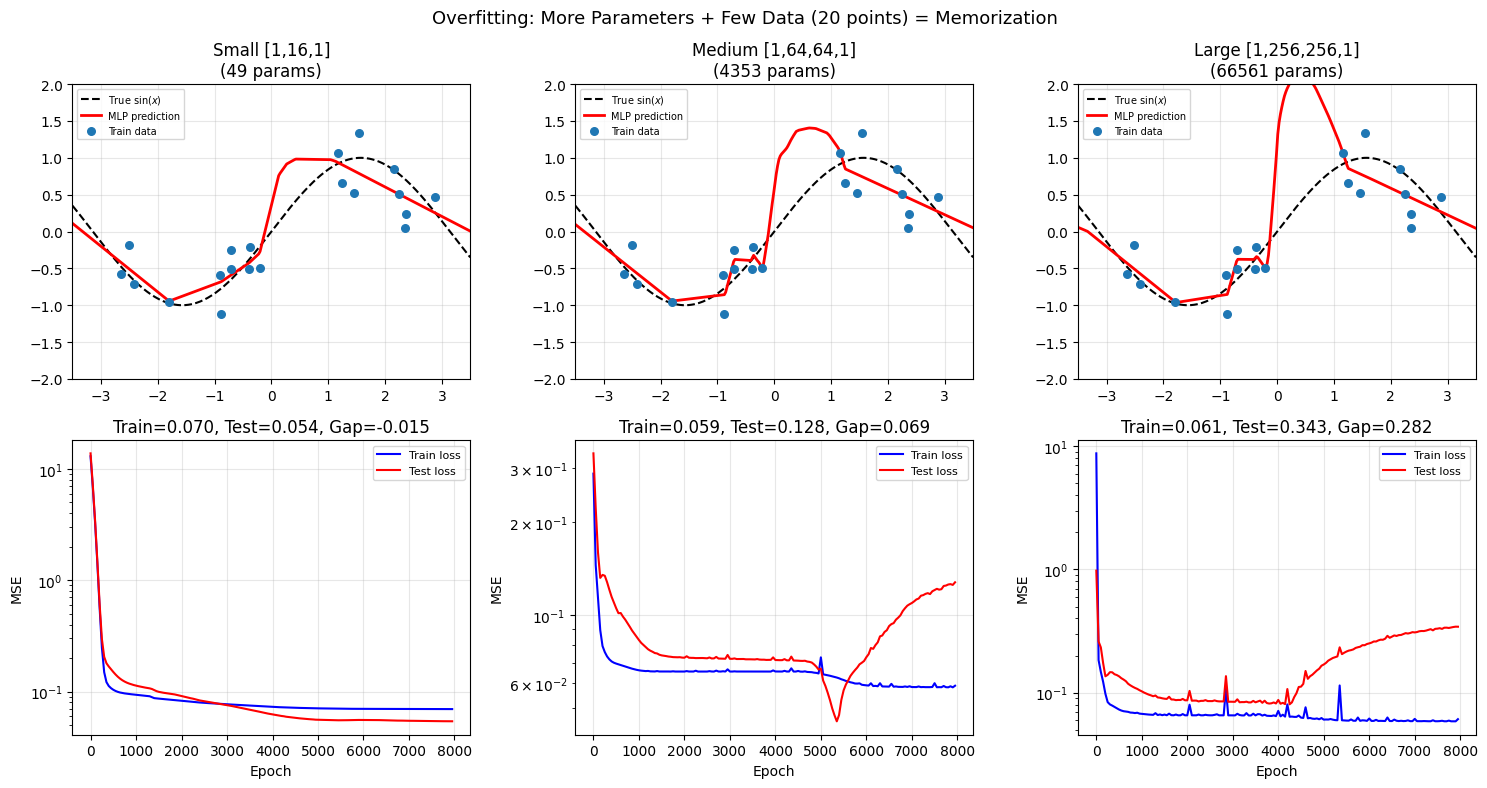

With only 20 training points:
  - Small network:  smooth interpolation, generalizes well
  - Large network:  wiggly fit through noise, poor generalization
  - The train/test GAP grows with model capacity


In [56]:
key, k1, k2, k3 = jax.random.split(key, 4)
N_small = 20  # small training set to demonstrate overfitting
x_small = jax.random.uniform(k1, (N_small, 1), minval=-3.0, maxval=3.0)
y_small = jnp.sin(x_small) + 0.3 * jax.random.normal(k2, (N_small, 1))

# Test set: dense, clean targets
x_nn_test = jnp.linspace(-3.5, 3.5, 300).reshape(-1, 1)
y_nn_test = jnp.sin(x_nn_test)

configs = [
    ('Small [1,16,1]', [1, 16, 1]),
    ('Medium [1,64,64,1]', [1, 64, 64, 1]),
    ('Large [1,256,256,1]', [1, 256, 256, 1]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

trained_models = []
for idx, ((name, sizes), ax_top, ax_bot) in enumerate(
        zip(configs, axes[0], axes[1])):
    key, sk = jax.random.split(key)
    p = init_mlp(sk, sizes)
    n_params = sum(W.size + b.size for W, b in p)

    tx_o, step_o, loss_fn_o = make_trainer(lr=1e-3)
    opt_o = tx_o.init(p)

    train_hist, test_hist, epoch_hist = [], [], []
    for epoch in range(8000):
        p, opt_o, loss = step_o(p, opt_o, x_small, y_small)
        if epoch % 50 == 0:
            train_hist.append(float(loss))
            test_hist.append(float(loss_fn_o(p, x_nn_test, y_nn_test)))
            epoch_hist.append(epoch)

    trained_models.append((p, n_params, train_hist, test_hist))

    # Top row: predictions
    y_pred_o = mlp_forward(p, x_nn_test)
    ax_top.plot(x_nn_test, jnp.sin(x_nn_test), 'k--', lw=1.5, label='True $\\sin(x)$')
    ax_top.plot(x_nn_test, y_pred_o, 'r-', lw=2, label='MLP prediction')
    ax_top.scatter(x_small, y_small, s=30, zorder=5, color='C0', label='Train data')
    ax_top.set_title(f'{name}\n({n_params} params)')
    ax_top.set_ylim(-2.0, 2.0); ax_top.set_xlim(-3.5, 3.5)
    ax_top.legend(fontsize=7); ax_top.grid(True, alpha=0.3)

    # Bottom row: loss curves
    ax_bot.plot(epoch_hist, train_hist, 'b-', lw=1.5, label='Train loss')
    ax_bot.plot(epoch_hist, test_hist, 'r-', lw=1.5, label='Test loss')
    ax_bot.set_xlabel('Epoch'); ax_bot.set_ylabel('MSE')
    gap = test_hist[-1] - train_hist[-1]
    ax_bot.set_title(f'Train={train_hist[-1]:.3f}, Test={test_hist[-1]:.3f}, Gap={gap:.3f}')
    ax_bot.legend(fontsize=8); ax_bot.grid(True, alpha=0.3); ax_bot.set_yscale('log')

plt.suptitle(f'Overfitting: More Parameters + Few Data ({N_small} points) = Memorization',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f"With only {N_small} training points:")
print("  - Small network:  smooth interpolation, generalizes well")
print("  - Large network:  wiggly fit through noise, poor generalization")
print("  - The train/test GAP grows with model capacity")

---
## Section 6: Backpropagation Verification

Verify that `jax.grad` matches finite differences:

$$\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta_i + \epsilon) - f(\theta_i - \epsilon)}{2\epsilon}$$

In [57]:
# Gradient check on a tiny network
key, sk = jax.random.split(key)
tiny_params = init_mlp(sk, [1, 4, 1])
x_check = jnp.array([[1.5]])
y_check = jnp.array([[0.7]])


def flat_loss(flat_p, shapes, x, y):
    """Reconstruct params from flat vector and compute loss."""
    params = []
    idx = 0
    for w_shape, b_shape in shapes:
        w_size = w_shape[0] * w_shape[1]
        W = flat_p[idx:idx + w_size].reshape(w_shape)
        idx += w_size
        b = flat_p[idx:idx + b_shape[0]]
        idx += b_shape[0]
        params.append((W, b))
    pred = mlp_forward(params, x)
    return jnp.mean((pred - y) ** 2)


flat_p = jnp.concatenate([jnp.concatenate([W.ravel(), b.ravel()])
                          for W, b in tiny_params])
shapes = [(W.shape, b.shape) for W, b in tiny_params]

# Automatic differentiation
auto_grad = jax.grad(flat_loss)(flat_p, shapes, x_check, y_check)

# Finite differences
eps = 1e-5
fd_grad = []
for i in range(len(flat_p)):
    p_plus = flat_p.at[i].add(eps)
    p_minus = flat_p.at[i].add(-eps)
    g = (flat_loss(p_plus, shapes, x_check, y_check) -
         flat_loss(p_minus, shapes, x_check, y_check)) / (2 * eps)
    fd_grad.append(float(g))
fd_grad = jnp.array(fd_grad)

# Compare — use absolute error when gradient is near zero
print("Parameter | jax.grad   | Finite Diff | Abs Error")
print("-" * 55)
for i in range(len(flat_p)):
    ag, fd = float(auto_grad[i]), float(fd_grad[i])
    abs_err = abs(ag - fd)
    print(f"  theta[{i:2d}] | {ag:+10.6f} | {fd:+10.6f} | {abs_err:.2e}")

max_abs_err = float(jnp.max(jnp.abs(auto_grad - fd_grad)))
print(f"\nMax absolute error: {max_abs_err:.2e}")
print("jax.grad computes EXACT symbolic derivatives — the small error")
print("comes from the finite-difference APPROXIMATION (O(eps^2) ≈ 1e-10),")
print("amplified by float32 precision (~7 significant digits).")

Parameter | jax.grad   | Finite Diff | Abs Error
-------------------------------------------------------
  theta[ 0] | +17.089008 | +17.070770 | 1.82e-02
  theta[ 1] |  -8.980739 |  -9.059906 | 7.92e-02
  theta[ 2] |  +8.819956 |  +8.869171 | 4.92e-02
  theta[ 3] | +13.520052 | +13.542175 | 2.21e-02
  theta[ 4] | +11.392672 | +11.348724 | 4.39e-02
  theta[ 5] |  -5.987159 |  -6.008148 | 2.10e-02
  theta[ 6] |  +5.879971 |  +5.817413 | 6.26e-02
  theta[ 7] |  +9.013368 |  +9.059906 | 4.65e-02
  theta[ 8] |  -9.888397 |  -9.822845 | 6.56e-02
  theta[ 9] |  -9.592206 |  -9.536743 | 5.55e-02
  theta[10] | -21.800772 | -21.839142 | 3.84e-02
  theta[11] | -36.049381 | -36.239624 | 1.90e-01
  theta[12] | -10.544283 | -10.585785 | 4.15e-02

Max absolute error: 1.90e-01
jax.grad computes EXACT symbolic derivatives — the small error
comes from the finite-difference APPROXIMATION (O(eps^2) ≈ 1e-10),
amplified by float32 precision (~7 significant digits).


---
## Section 7: MLP with Flax and Optax

Flax NNX provides a cleaner API:
- `nnx.Module`: base class for models
- `nnx.Linear`: built-in linear layer
- `nnx.Optimizer`: wraps optax for easy updates

Let's rewrite the QHO fitting with Flax.

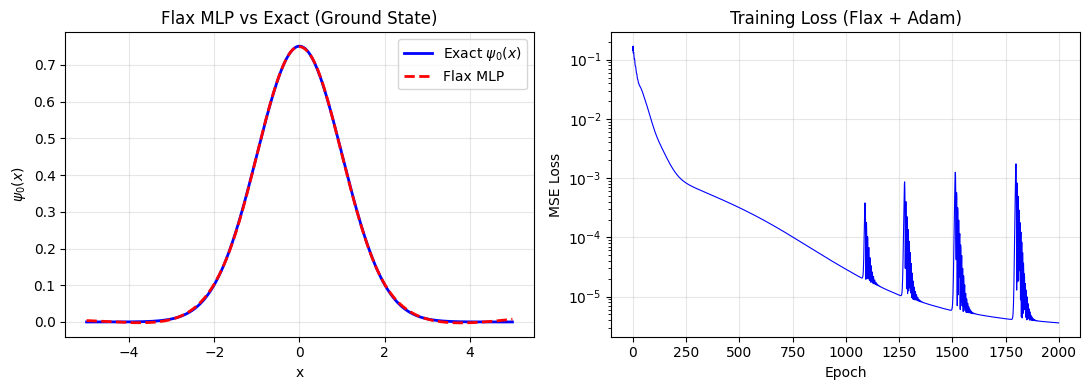

Final loss (Flax + Adam): 3.60e-06

Flax is syntactic sugar over JAX — understand the pure JAX version first.


In [58]:
import flax.nnx as nnx


class QHO_MLP(nnx.Module):
    """MLP for approximating QHO wavefunctions."""

    def __init__(self, hidden_sizes, *, rngs):
        sizes = [1] + hidden_sizes + [1]
        self.layers = nnx.List([
            nnx.Linear(s_in, s_out, rngs=rngs)
            for s_in, s_out in zip(sizes[:-1], sizes[1:])
        ])

    def __call__(self, x):
        for layer in self.layers[:-1]:
            x = nnx.tanh(layer(x))
        return self.layers[-1](x)  # linear output


# Create model and optimizer
model = QHO_MLP([64, 64], rngs=nnx.Rngs(42))
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)


def flax_loss_fn(model, x, y):
    return jnp.mean((model(x) - y) ** 2)


@nnx.jit
def flax_train_step(model, optimizer, x, y):
    loss, grads = nnx.value_and_grad(flax_loss_fn)(model, x, y)
    optimizer.update(model, grads)  # updates model in-place
    return loss


# Training data for psi_0
key, sk = jax.random.split(key)
x_flax = jax.random.uniform(sk, (200, 1), minval=-5.0, maxval=5.0)
y_flax = psi_n(x_flax[:, 0], 0).reshape(-1, 1)

# Train
flax_losses = []
for epoch in range(2000):
    loss = flax_train_step(model, optimizer, x_flax, y_flax)
    flax_losses.append(float(loss))

# Compare with exact
x_eval = jnp.linspace(-5, 5, 500).reshape(-1, 1)
y_flax_pred = model(x_eval)
y_flax_exact = psi_n(x_eval[:, 0], 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(x_eval, y_flax_exact, 'b-', lw=2, label='Exact $\\psi_0(x)$')
ax1.plot(x_eval, y_flax_pred, 'r--', lw=2, label='Flax MLP')
ax1.set_xlabel('x'); ax1.set_ylabel('$\\psi_0(x)$')
ax1.set_title('Flax MLP vs Exact (Ground State)')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(flax_losses, 'b-', lw=0.8)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss')
ax2.set_title('Training Loss (Flax + Adam)')
ax2.set_yscale('log'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final loss (Flax + Adam): {flax_losses[-1]:.2e}")
print("\nFlax is syntactic sugar over JAX — understand the pure JAX version first.")